# Admin Updates
- Early voting ends Friday (can register in person. ([Info sheet from state](https://s3.amazonaws.com/dl.ncsbe.gov/Voter%20ID/2024-09-College-Student-Infosheet.pdf)/[State website for college students](https://www.ncsbe.gov/registering/who-can-register/registering-college-student))
- Individual assesment Monday
- Group assesment due at start of class on Monday (think of it as a mini-project)
- Schedule Updates
 - Project introduction Wed
 - Start of new unit following Mon (you'll have a few hours of pre-class work)

1. In class, we assumed fixed numbers for our monthly contribution while saving and monthly withdraw while retired. Instead, I would like to assume we are contributing a percentage of our salary. Adjust the model to assume a fixed salary (a new variable), and assume a percentage of our monthly income we will contribute each month (a new variable) which will replace the "investAmount" variable. (For example if we are making \$50,000 per year and contributing \$1000 per month, our contribution is 24%).
1. Adjust the model to assume that in retirement rather than withdrawing a fixed amount of money we are withdrawing a percent of our income at retirement age. This should add a variable in our model to replace the "spendingAmount" variable in use. (For example if we are making \$50,000 per year at retirement and withdrawing \$4000 per month, our withdraw rate is 96%).
1. Our contributions and withdraws now are determined by three variables. Salary, contribution rate, and withdraw rate. Keeping the contribution and withdraw rates the same, how does the retirement age depend on the salary?
1. In reality, you usually do not make the same amount of money each year of your life. Let's break that assumption. Instead, let's assume each year you are working you get a fixed percentage raise (assume 1% above the inflation rate which is 0% in our model). Add a variable to track that percentage yearly raise and adjust your model so your salary is adjusted upwards at the end of each year you are working (and since you are contributing a percentage of your income, your monthly contributions are as well). Using your adjusted model, what is your new retirement age? How much money are we withdrawing each month in retirement? What was our salary at retirement?
1. Suppose in retirement we live off of the same amount we did when we were working (our withdraw rate is 1 - our contribution rate). What is our retirement age?
1. Suppose we can only contribute 10% of our income each month, what is our retirement age?
1. Assuming we contribute 15% of our income, and we require 70% in retirement, what is our retirement age? What is our retirement age if we lived to 90 instead of 85? What is our retirement age if we want to make sure our IRA is still growing over retirement (i.e. the balance never decreases).

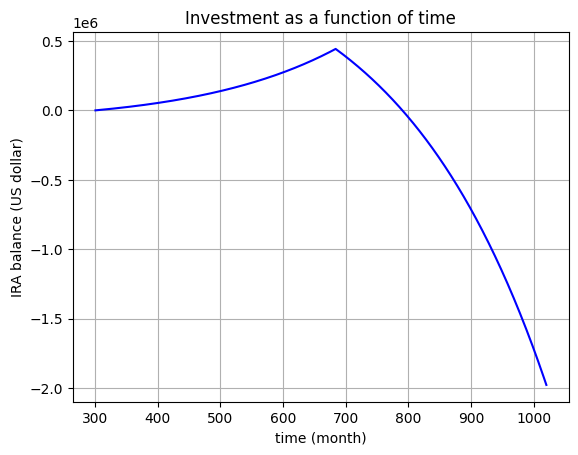

In [14]:
import matplotlib.pyplot as plt
# Outline of code

# Write our assumptions as variables (inputs)
age_death = 85*12 # in years
age_retire = 57*12
age = 25*12
IRA = 0

# Market assumptions
dt = 1 #month
r = 0.07/12 #return rate per month
r_inflation = 0.02/12 #inflation per month
r = r - r_inflation # Inflation adjusted rate per month

salary = 50000 / 12 # per month
r_contrib = 0.10
r_spending = 1-r_contrib

r_raise = 0.01 # per year

# Lists for storing IRA balance
age_list = []
balance_list = []

# Loop over time from 25 until death
while age < age_death:

  contrib = salary * r_contrib # per month
  spending = salary * r_spending # per month

  # inrease the balance by interest
  interest = IRA * r * dt
  IRA = IRA + interest

  # if age < retirement: Increase balance by our contribution (new money we're putting in)
  if age < age_retire:
     # Do raise
    if age % 12 == 11:
      salary = salary + salary*r_raise
    IRA = IRA + contrib
  # else: Draw down IRA (subtract spending)
  else:
    IRA = IRA - spending

  age = age + dt

  # Save balance for graphing
  age_list.append(age)
  balance_list.append(IRA)


# Plot
fig = plt.figure()
plt.title("Investment as a function of time")
plt.xlabel('time (month)')
plt.ylabel('IRA balance (US dollar)')
plt.plot(age_list, balance_list, 'b-')
plt.grid()
plt.show()

